In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bisect
import lightgbm as lgb
from scipy.stats import spearmanr
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, '/Users/nishiharahiroto/Documents/programs/market-analytics-ver1')
from data.utils.database_manager import DatabaseManager

# ---- 定数 ----
ALL_TENORS   = ['3M', '6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '6Y', '7Y']
INNER_TENORS = ['6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '6Y']
MACRO_COLS   = ['USDJPY', 'DXY', 'nikkei', 'ust10y']
D, WINDOW    = 0.4, 50
OOS_START    = '2024-01-01'
OUTPUT_DIR   = '../outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')


In [2]:
db = DatabaseManager()

# --- OIS ---
rows = db.get_ois_data(product_type='OIS')
df_swap_raw = pd.DataFrame(rows)
df_swap_raw['trade_date'] = pd.to_datetime(df_swap_raw['trade_date'])
df_ois_wide = df_swap_raw.pivot(index='trade_date', columns='tenor', values='rate')

available_tenors = [t for t in ALL_TENORS if t in df_ois_wide.columns]
missing_tenors   = [t for t in ALL_TENORS if t not in df_ois_wide.columns]
print(f"Available : {available_tenors}")
print(f"Missing   : {missing_tenors}")
df_ois = df_ois_wide[available_tenors].sort_index()

# Inner tenors: 両隣が available_tenors に揃っているものだけ残す
avail_set = set(available_tenors)
available_inner = [
    t for t in INNER_TENORS
    if t in avail_set
    and ALL_TENORS[ALL_TENORS.index(t) - 1] in avail_set
    and ALL_TENORS[ALL_TENORS.index(t) + 1] in avail_set
]
print(f"Inner tenors for butterfly: {available_inner}")

# --- Macro ---
fx_q  = "SELECT trade_date, currency_pair, close_price FROM exchange_rates WHERE currency_pair IN ('USDJPY', 'DXY')"
df_fx = pd.DataFrame(db.select_as_dict(fx_q))
df_fx['trade_date'] = pd.to_datetime(df_fx['trade_date'])
df_fx = df_fx.pivot(index='trade_date', columns='currency_pair', values='close_price')

nk_q  = "SELECT trade_date, close_price as nikkei FROM stock_prices WHERE ticker = '^N225'"
df_nk = pd.DataFrame(db.select_as_dict(nk_q))
df_nk['trade_date'] = pd.to_datetime(df_nk['trade_date'])
df_nk = df_nk.set_index('trade_date')[['nikkei']]

us_q  = "SELECT trade_date, yield_value as ust10y FROM foreign_yields WHERE region = 'US' AND tenor = '10Y'"
df_us = pd.DataFrame(db.select_as_dict(us_q))
df_us['trade_date'] = pd.to_datetime(df_us['trade_date'])
df_us = df_us.set_index('trade_date')[['ust10y']]

boj_q = "SELECT meeting_date, policy_rate_after as policy_rate FROM boj_meetings ORDER BY meeting_date"
df_boj = pd.DataFrame(db.select_as_dict(boj_q))
df_boj['meeting_date'] = pd.to_datetime(df_boj['meeting_date'])
df_boj['policy_rate'] = df_boj['policy_rate'].astype(float)

print(f"OIS range: {df_ois.index.min().date()} ~ {df_ois.index.max().date()}, rows={len(df_ois)}")


INFO:data.utils.database_manager:DatabaseManager initialized for ep-calm-boat-a1zzrjkt-pooler.ap-southeast-1.aws.neon.tech


Available : ['3M', '6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '6Y', '7Y']
Missing   : []
Inner tenors for butterfly: ['6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '6Y']


OIS range: 2014-06-23 ~ 2026-03-27, rows=2874


In [3]:
# --- Outer join ---
df_all = df_ois.join([df_fx, df_nk, df_us], how='outer').sort_index()
df_all = df_all.dropna(how='all')
for col in df_all.columns:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# --- 補完フラグ（補完前に生成）---
numeric_cols = [c for c in df_all.columns if not c.endswith('_is_imputed')]
for col in numeric_cols:
    df_all[f'{col}_is_imputed'] = df_all[col].isna().astype(int)

# --- MICE 補完 ---
scaler  = StandardScaler()
df_sc   = pd.DataFrame(scaler.fit_transform(df_all[numeric_cols]),
                        columns=numeric_cols, index=df_all.index)
imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)
df_all[numeric_cols] = scaler.inverse_transform(imputer.fit_transform(df_sc))
print("MICE imputation done.")

# --- 日銀カレンダー ---
df_boj_daily = df_boj.set_index('meeting_date')[['policy_rate']]
df_all['policy_rate'] = df_boj_daily.reindex(df_all.index, method='ffill')['policy_rate']

meeting_dates = df_boj['meeting_date'].sort_values().values
def days_to_next(date):
    future = meeting_dates[meeting_dates > date]
    return int((future[0] - date).days) if len(future) > 0 else np.nan
df_all['days_to_next_mpm'] = [days_to_next(d) for d in df_all.index]

df_all['is_meeting_day'] = df_all.index.isin(df_boj['meeting_date']).astype(int)
df_all['is_post_mpm']    = df_all['is_meeting_day'].rolling(window=6, min_periods=1).max().astype(int)
print("BOJ calendar done.")


MICE imputation done.
BOJ calendar done.


/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/3958283287.py:23: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/3958283287.py:23: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/3958283287.py:23: UserWarning: Glyph 20596 (\N{CJK UNIFIED IDEOGRAPH-5074}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/3958283287.py:23: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/3958283287.py:23: UserWarning: Glyph 12490 (\N{KATAKANA LETTER NA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/3

Butterfly tenors: ['6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '6Y']
       mean     std     min     max
6M   0.0018  0.0043 -0.0506  0.0338
9M   0.0049  0.0051 -0.0200  0.0217
1Y  -0.0087  0.0067 -0.0674  0.0269
18M  0.0059  0.0060 -0.0262  0.0256
2Y  -0.0108  0.0062 -0.0650  0.0138
3Y   0.0010  0.0073 -0.0675  0.0613
4Y  -0.0051  0.0037 -0.0419  0.0287
5Y  -0.0096  0.0056 -0.0313  0.0181
6Y  -0.0087  0.0047 -0.0300  0.0100


/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20596 (\N{CJK UNIFIED IDEOGRAPH-5074}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) Arial.
  fig.canvas.print

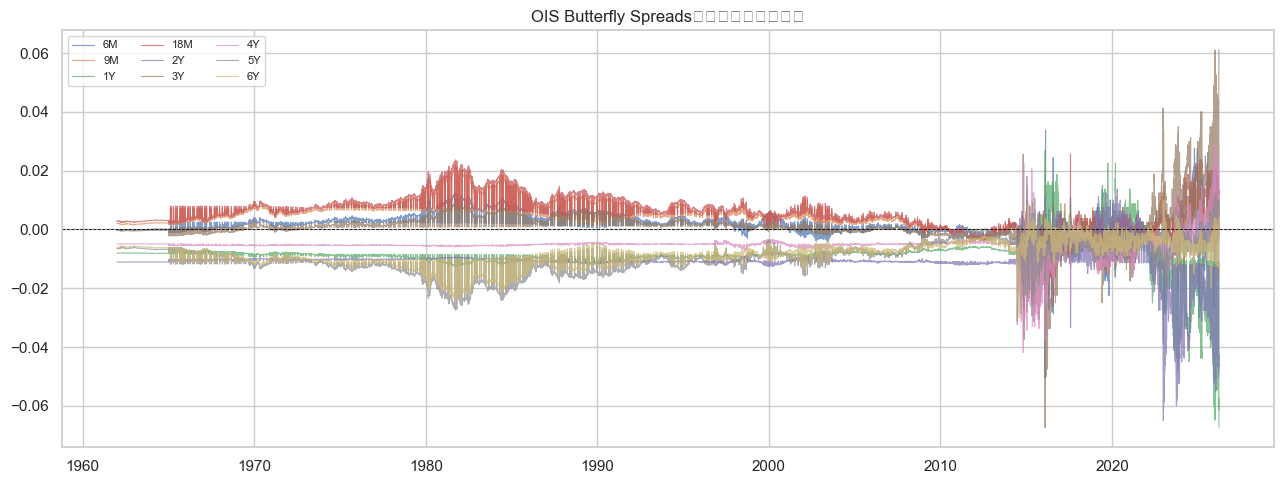

In [4]:
def compute_butterfly(df_ois: pd.DataFrame, all_tenors: list, inner_tenors: list) -> pd.DataFrame:
    """内側テナーのみバタフライを計算（端点 3M/7Y は除外）。"""
    bf = pd.DataFrame(index=df_ois.index)
    for t in inner_tenors:
        idx    = all_tenors.index(t)
        prev_t = all_tenors[idx - 1]
        next_t = all_tenors[idx + 1]
        bf[t]  = 2 * df_ois[t] - df_ois[prev_t] - df_ois[next_t]
    return bf

ois_imputed = df_all[[t for t in available_tenors]]
df_bf = compute_butterfly(ois_imputed, available_tenors, available_inner)

print("Butterfly tenors:", df_bf.columns.tolist())
print(df_bf.describe().T[['mean','std','min','max']].round(4))

fig, ax = plt.subplots(figsize=(13, 5))
for t in df_bf.columns:
    ax.plot(df_bf.index, df_bf[t], label=t, alpha=0.7, linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_title("OIS Butterfly Spreads（内側テナーのみ）")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}bf_base_overview.png", dpi=150)
plt.show()


In [5]:
def frac_diff(series: pd.Series, d: float = 0.4, window: int = 50) -> pd.Series:
    """固定ウィンドウ法による分数階差。先頭 window-1 行は NaN。"""
    weights = [1.0]
    for k in range(1, window):
        weights.append(-weights[-1] * (d - k + 1) / k)
    weights = np.array(weights[::-1])
    arr = series.to_numpy(dtype=float)
    n, result = len(arr), np.full(len(arr), np.nan)
    if n < window:
        return pd.Series(result, index=series.index)
    from numpy.lib.stride_tricks import sliding_window_view
    wv   = sliding_window_view(arr, window_shape=window)
    dots = wv @ weights
    dots[np.isnan(wv).any(axis=1)] = np.nan
    result[window - 1:] = dots
    return pd.Series(result, index=series.index)

# --- マクロ FD（分数階差のみ）---
macro_fd = {f'{m}_fd': frac_diff(df_all[m], D, WINDOW)
            for m in MACRO_COLS if m in df_all.columns}

# --- 共通コンテキスト（水準のまま）---
df_all['front_spread'] = df_all['3M'] - df_all['policy_rate']   # M1_spread 相当
df_all['slope_3m7y']   = df_all['7Y'] - df_all['3M']            # Slope_M1M8 相当

# --- バタフライの FD ---
bf_fd = {t: frac_diff(df_bf[t], D, WINDOW) for t in df_bf.columns}

print("Macro FD columns :", list(macro_fd.keys()))
print("BF FD tenors     :", list(bf_fd.keys()))


Macro FD columns : ['USDJPY_fd', 'DXY_fd', 'nikkei_fd', 'ust10y_fd']
BF FD tenors     : ['6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '6Y']


In [6]:
NON_FEATURE_COLS = {'tenor_index', 'target', 'target_std', 'target_norm'}

# tenor → 整数コードのマッピング（モデルへの特徴量として使う）
TENOR_CODE_MAP = {t: i for i, t in enumerate(INNER_TENORS)}

def build_pooled_df(h: int, config: str) -> pd.DataFrame:
    """
    目的変数: バタフライ変化量 BF_{t+h} - BF_t（テナー別 std 正規化）

    Config A: bf_level（1本）+ bf_fd（1本）+ 共通コンテキスト
    Config B: Config A + 全内側テナーの bf_level と bf_fd を追加

    tenor_index : グループ化・IC計算用の文字列（モデルには渡さない）
    tenor_code  : テナー識別子の整数コード（モデルに特徴量として渡す）
    """
    flag_cols = [c for c in df_all.columns if c.endswith('_is_imputed')]
    all_rows  = []

    for tenor in available_inner:
        bf_s   = df_bf[tenor]
        target = bf_s.shift(-h) - bf_s      # バタフライ変化量（目的変数）

        row = {
            # ── ガイド準拠の特徴量 ──────────────────────────────
            'tenor_code':        TENOR_CODE_MAP.get(tenor, 0),  # Meeting_Index 相当
            'bf_level':          bf_s,                           # Fly_Level 相当
            'bf_fd':             bf_fd[tenor],                   # B{n}_frac_diff 相当
            'front_spread':      df_all['front_spread'],         # M1_spread 相当（水準）
            'slope_3m7y':        df_all['slope_3m7y'],           # Slope_M1M8 相当（水準）
            'policy_rate':       df_all['policy_rate'],          # Actual_Policy_Rate（水準）
            'days_to_next_mpm':  df_all['days_to_next_mpm'],
        }

        # Config B: 全内側テナーのバタフライ水準・FD を追加
        if config == 'B':
            for t in available_inner:
                row[f'bf_level_{t}'] = df_bf[t]
                row[f'bf_fd_{t}']    = bf_fd[t]

        # マクロ FD
        for col, s in macro_fd.items():
            row[col] = s

        # 補完フラグ
        for fc in flag_cols:
            row[fc] = df_all[fc]

        # is_post_mpm（除外用・モデルには渡さない）
        row['is_post_mpm'] = df_all['is_post_mpm']

        tmp = pd.DataFrame({'tenor_index': tenor, **row, 'target': target},
                           index=df_all.index)
        all_rows.append(tmp)

    df_long = pd.concat(all_rows).sort_index()

    # NaN 除去（FD ウォームアップ期間 + target 末尾 h 行）
    feat_cols = [c for c in df_long.columns if c not in NON_FEATURE_COLS | {'is_post_mpm'}]
    df_long   = df_long.dropna(subset=feat_cols + ['target'])

    # MPM 直後除外
    df_long = df_long[df_long['is_post_mpm'] == 0].drop(columns='is_post_mpm')

    # 目的変数正規化（テナー別全期間 std）
    df_long['target_std']  = df_long.groupby('tenor_index')['target'].transform('std')
    df_long['target_norm'] = df_long['target'] / df_long['target_std']

    return df_long

# 動作確認
_tmp = build_pooled_df(h=3, config='A')
print(f"Config A h=3 shape: {_tmp.shape}")
print("Features:", [c for c in _tmp.columns if c not in NON_FEATURE_COLS])
del _tmp


Config A h=3 shape: (33417, 30)
Features: ['tenor_code', 'bf_level', 'bf_fd', 'front_spread', 'slope_3m7y', 'policy_rate', 'days_to_next_mpm', 'USDJPY_fd', 'DXY_fd', 'nikkei_fd', 'ust10y_fd', '3M_is_imputed', '6M_is_imputed', '9M_is_imputed', '1Y_is_imputed', '18M_is_imputed', '2Y_is_imputed', '3Y_is_imputed', '4Y_is_imputed', '5Y_is_imputed', '6Y_is_imputed', '7Y_is_imputed', 'DXY_is_imputed', 'USDJPY_is_imputed', 'nikkei_is_imputed', 'ust10y_is_imputed']


In [7]:
PARAMS = {
    'objective': 'regression', 'metric': 'rmse', 'verbosity': -1,
    'boosting_type': 'gbdt', 'random_state': 42, 'learning_rate': 0.05,
    'num_leaves': 31, 'feature_fraction': 0.8, 'bagging_fraction': 0.8,
    'bagging_freq': 5, 'min_data_in_leaf': 30, 'lambda_l2': 1.0,
}
NUM_BOOST_ROUND  = 100
TEST_WINDOW_DAYS = 90
PURGE_DAYS       = 5

def walk_forward(df_long: pd.DataFrame, oos_start: str) -> pd.DataFrame:
    target_col   = 'target_norm'
    feature_cols = [c for c in df_long.columns if c not in NON_FEATURE_COLS]

    # tenor_index を category dtype に変換（LightGBM が自動認識）
    df_long = df_long.copy()
    df_long['tenor_index'] = df_long['tenor_index'].astype('category')

    unique_dates = sorted(df_long.index.unique())
    start_idx    = bisect.bisect_left(unique_dates, pd.to_datetime(oos_start))

    results, fold, current_idx = [], 0, start_idx
    while current_idx < len(unique_dates):
        train_end  = unique_dates[current_idx - 1]
        purge_end  = train_end - pd.Timedelta(days=PURGE_DAYS)
        test_start = unique_dates[current_idx]
        test_end   = test_start + pd.Timedelta(days=TEST_WINDOW_DAYS)

        train_mask = df_long.index <= purge_end
        test_mask  = (df_long.index >= test_start) & (df_long.index < test_end)

        if train_mask.sum() < 100 or test_mask.sum() < 10:
            current_idx = bisect.bisect_left(unique_dates, test_end)
            continue

        X_tr, y_tr = df_long.loc[train_mask, feature_cols], df_long.loc[train_mask, target_col]
        X_te       = df_long.loc[test_mask,  feature_cols]

        # categorical_feature は指定せず dtype='category' で自動認識
        dtrain   = lgb.Dataset(X_tr, label=y_tr)
        model    = lgb.train(PARAMS, dtrain, num_boost_round=NUM_BOOST_ROUND)
        preds    = model.predict(X_te)
        train_ic = spearmanr(y_tr, model.predict(X_tr))[0]

        fold_df = df_long.loc[test_mask, ['tenor_index', 'target', 'target_std']].copy()
        fold_df['pred_norm'] = preds
        fold_df['pred']      = preds * fold_df['target_std']
        fold_df['actual']    = fold_df['target']
        fold_df['fold']      = fold
        fold_df['train_ic']  = train_ic
        results.append(fold_df)

        fold += 1
        current_idx = bisect.bisect_left(unique_dates, test_end)

    return pd.concat(results).reset_index(names='date') if results else pd.DataFrame()


def summarize_ic(res: pd.DataFrame, recent_n: int = 3) -> dict:
    if res.empty:
        return {}
    ic_all = spearmanr(res['actual'], res['pred_norm'])[0]

    cs_ics = [spearmanr(g['actual'], g['pred_norm'])[0]
              for _, g in res.groupby('date') if len(g) >= 3]
    cs_ic  = np.nanmean(cs_ics) if cs_ics else np.nan

    ts_ics = [spearmanr(g['actual'], g['pred_norm'])[0]
              for _, g in res.groupby('tenor_index') if len(g) >= 5]
    ts_ic  = np.nanmean(ts_ics) if ts_ics else np.nan

    recent_folds = sorted(res['fold'].unique())[-recent_n:]
    ic_recent    = spearmanr(res.loc[res['fold'].isin(recent_folds), 'actual'],
                             res.loc[res['fold'].isin(recent_folds), 'pred_norm'])[0]
    train_ic = res.groupby('fold')['train_ic'].first().mean()

    return dict(ic_all=ic_all, cs_ic=cs_ic, ts_ic=ts_ic,
                ic_recent=ic_recent, train_ic=train_ic, gap=train_ic - ic_all)


In [8]:
print("=" * 50)
print("Config A: bf_level 1本（予測対象テナーのみ）")
print("=" * 50)

results_A, walk_A = {}, {}
for h in [3, 5]:
    df_long = build_pooled_df(h=h, config='A')
    res     = walk_forward(df_long, OOS_START)
    stats   = summarize_ic(res)
    results_A[h] = stats
    walk_A[h]    = res
    print(f"h={h}: Global IC={stats.get('ic_all',0):.3f}, "
          f"CS IC={stats.get('cs_ic',0):.3f}, "
          f"TS IC={stats.get('ts_ic',0):.3f}, "
          f"Gap={stats.get('gap',0):.3f}, "
          f"ic_recent={stats.get('ic_recent',0):.3f}")


Config A: bf_level 1本（予測対象テナーのみ）


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/4147042984.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in res.groupby('tenor_index') if len(g) >= 5]


h=3: Global IC=0.262, CS IC=0.175, TS IC=0.285, Gap=0.141, ic_recent=0.302


h=5: Global IC=0.239, CS IC=0.127, TS IC=0.270, Gap=0.192, ic_recent=0.296


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/4147042984.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in res.groupby('tenor_index') if len(g) >= 5]


In [9]:
print("=" * 50)
print("Config B: bf_level 全内側テナー分追加")
print("=" * 50)

results_B, walk_B = {}, {}
for h in [3, 5]:
    df_long = build_pooled_df(h=h, config='B')
    res     = walk_forward(df_long, OOS_START)
    stats   = summarize_ic(res)
    results_B[h] = stats
    walk_B[h]    = res
    print(f"h={h}: Global IC={stats.get('ic_all',0):.3f}, "
          f"CS IC={stats.get('cs_ic',0):.3f}, "
          f"TS IC={stats.get('ts_ic',0):.3f}, "
          f"Gap={stats.get('gap',0):.3f}, "
          f"ic_recent={stats.get('ic_recent',0):.3f}")


Config B: bf_level 全内側テナー分追加


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/4147042984.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in res.groupby('tenor_index') if len(g) >= 5]


h=3: Global IC=0.252, CS IC=0.170, TS IC=0.277, Gap=0.157, ic_recent=0.301


h=5: Global IC=0.243, CS IC=0.131, TS IC=0.280, Gap=0.198, ic_recent=0.285


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/4147042984.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in res.groupby('tenor_index') if len(g) >= 5]


In [10]:
rows = []
for config, results in [('A', results_A), ('B', results_B)]:
    for h, s in results.items():
        rows.append({'Config': config, 'h': h,
                     'Global IC': round(s.get('ic_all',    np.nan), 3),
                     'CS IC':     round(s.get('cs_ic',     np.nan), 3),
                     'TS IC':     round(s.get('ts_ic',     np.nan), 3),
                     'Gap':       round(s.get('gap',       np.nan), 3),
                     'ic_recent': round(s.get('ic_recent', np.nan), 3)})
df_cmp = pd.DataFrame(rows).set_index(['Config', 'h'])
display(df_cmp)


Global IC  CS IC  TS IC    Gap  ic_recent
Config h                                           
A      3      0.262  0.175  0.285  0.141      0.302
       5      0.239  0.127  0.270  0.192      0.296
B      3      0.252  0.170  0.277  0.157      0.301
       5      0.243  0.131  0.280  0.198      0.285

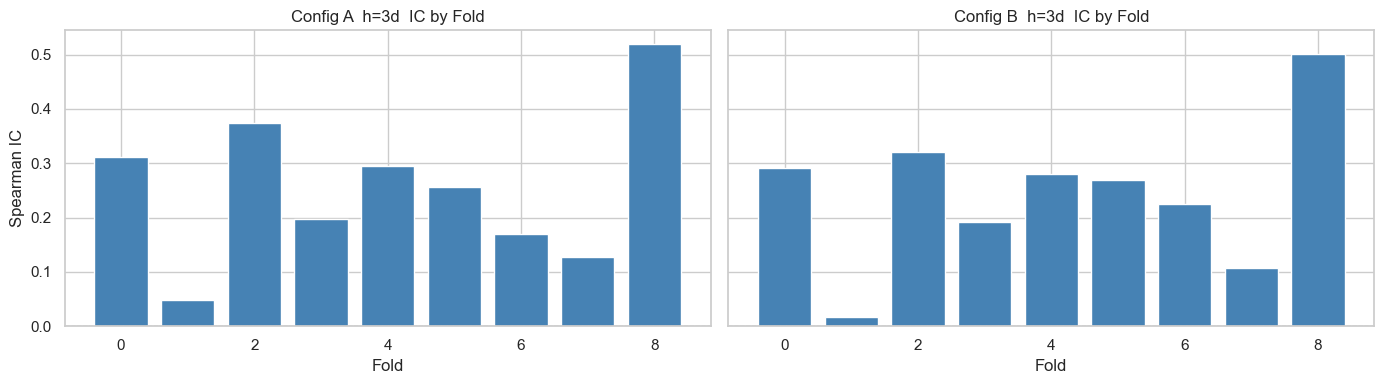

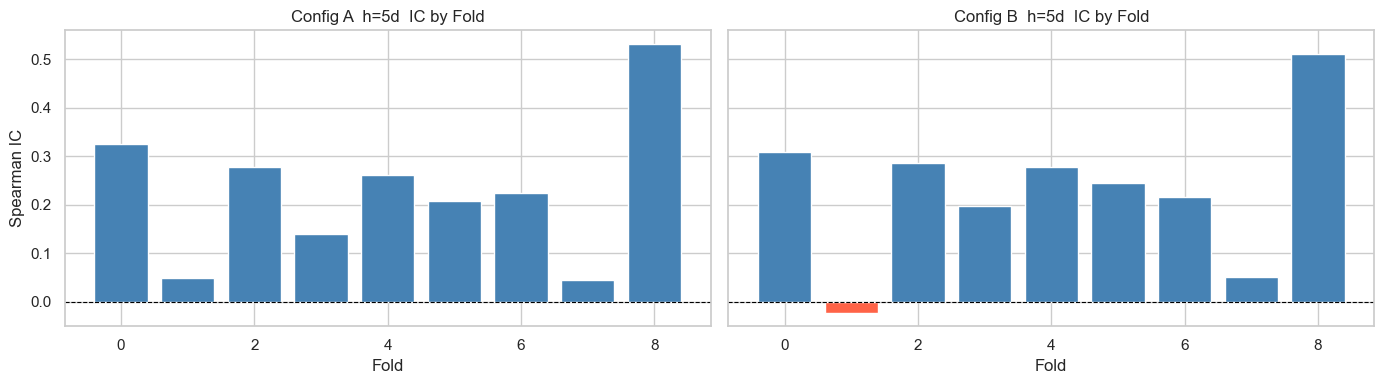

In [11]:
for h in [3, 5]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for ax, (config, walk) in zip(axes, [('A', walk_A), ('B', walk_B)]):
        res = walk[h]
        if res.empty:
            continue
        fold_ics = [spearmanr(g['actual'], g['pred_norm'])[0]
                    for _, g in res.groupby('fold')]
        ax.bar(range(len(fold_ics)), fold_ics,
               color=['steelblue' if v >= 0 else 'tomato' for v in fold_ics])
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(f"Config {config}  h={h}d  IC by Fold")
        ax.set_xlabel("Fold")
    axes[0].set_ylabel("Spearman IC")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}bf_base_ic_by_fold_{h}d.png", dpi=150)
    plt.show()


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/3086931949.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenor_ics = res.groupby('tenor_index').apply(
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/3086931949.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenor_ics = res.groupby('tenor_index').apply(


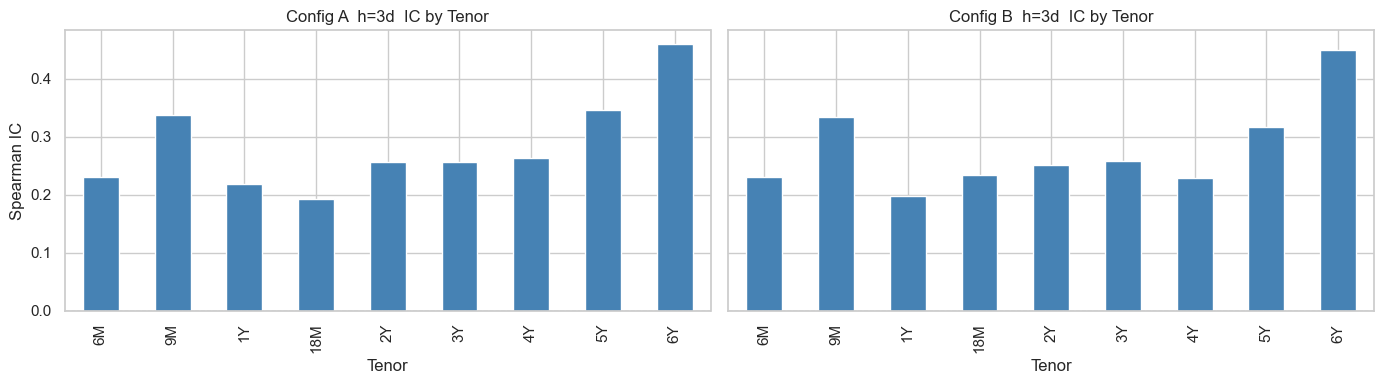

/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/3086931949.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenor_ics = res.groupby('tenor_index').apply(
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_22866/3086931949.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenor_ics = res.groupby('tenor_index').apply(


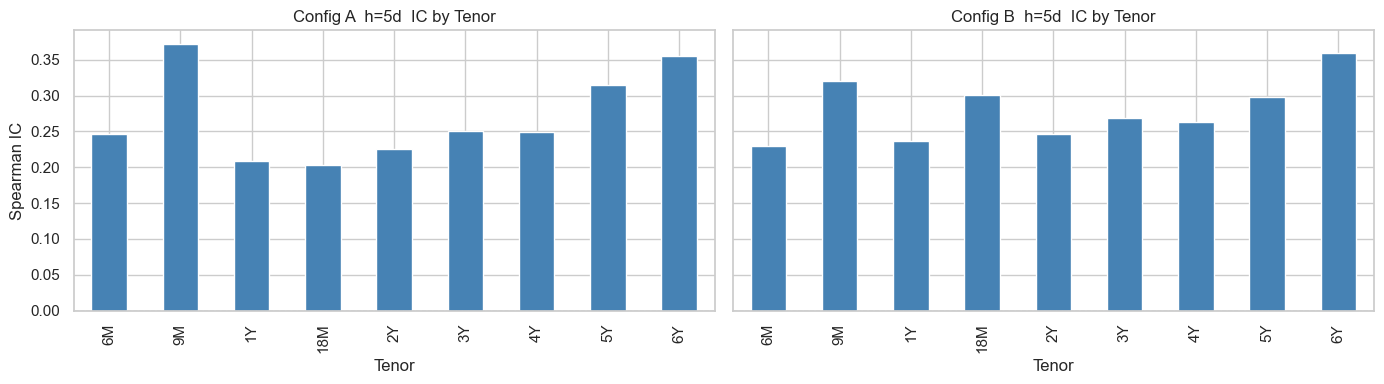

In [12]:
for h in [3, 5]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for ax, (config, walk) in zip(axes, [('A', walk_A), ('B', walk_B)]):
        res = walk[h]
        if res.empty:
            continue
        tenor_ics = res.groupby('tenor_index').apply(
            lambda x: spearmanr(x['actual'], x['pred_norm'])[0], include_groups=False
        ).reindex(available_inner)
        tenor_ics.plot(kind='bar', ax=ax,
                       color=['steelblue' if v >= 0 else 'tomato' for v in tenor_ics])
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(f"Config {config}  h={h}d  IC by Tenor")
        ax.set_xlabel("Tenor")
    axes[0].set_ylabel("Spearman IC")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}bf_base_ic_by_tenor_{h}d.png", dpi=150)
    plt.show()


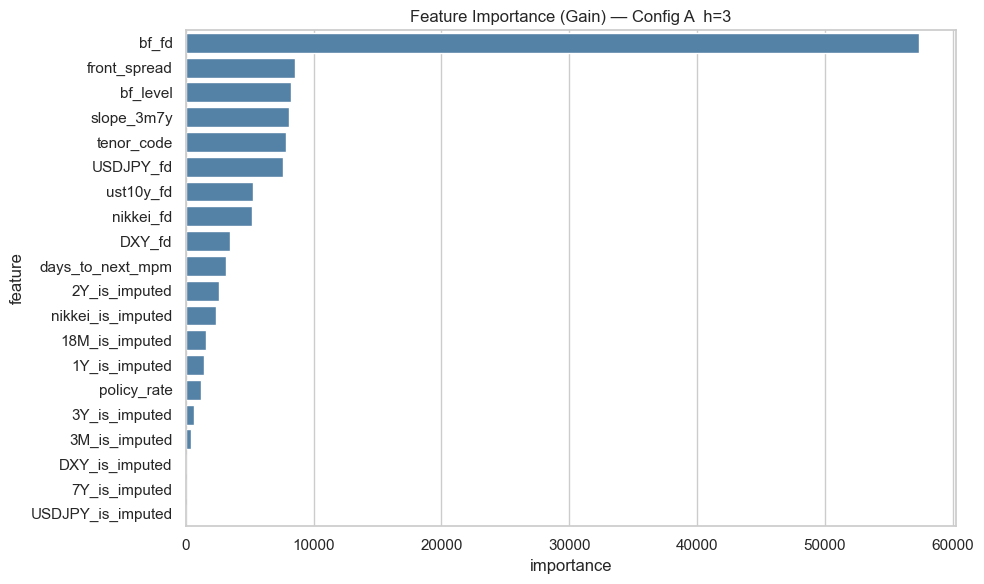

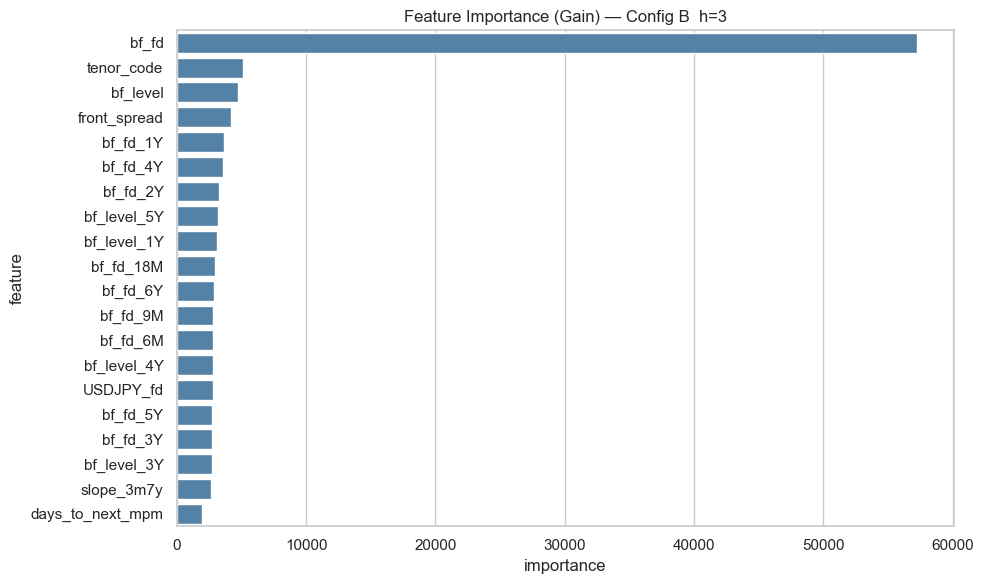

In [13]:
for config in ['A', 'B']:
    df_long = build_pooled_df(h=3, config=config)
    feat_cols = [c for c in df_long.columns if c not in NON_FEATURE_COLS]
    df_tmp = df_long.copy()
    dtrain = lgb.Dataset(df_tmp[feat_cols], label=df_tmp['target_norm'])
    model  = lgb.train(PARAMS, dtrain, num_boost_round=NUM_BOOST_ROUND)
    imp = pd.DataFrame({'feature':    feat_cols,
                        'importance': model.feature_importance(importance_type='gain')}
                      ).sort_values('importance', ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp.head(20), x='importance', y='feature', color='steelblue')
    plt.title(f"Feature Importance (Gain) — Config {config}  h=3")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}bf_base_importance_{config}.png", dpi=150)
    plt.show()


## 結果サマリー

```
モデル名  : spot_rate_bf_base
目的変数  : バタフライ変化量 BF_{t+h} − BF_t
対象テナー: 6M, 9M, 1Y, 18M, 2Y, 3Y, 4Y, 5Y, 6Y（端点 3M/7Y はプーリング除外）
OOS開始日 : 2024-01-01
rounds    : 100

--- h=3 ---
Config A (bf_level 1本): Global IC=X.XXX, CS IC=X.XXX, TS IC=X.XXX, Gap=X.XXX
Config B (bf_level 全本): Global IC=X.XXX, CS IC=X.XXX, TS IC=X.XXX, Gap=X.XXX

--- h=5 ---
Config A (bf_level 1本): Global IC=X.XXX, CS IC=X.XXX, TS IC=X.XXX, Gap=X.XXX
Config B (bf_level 全本): Global IC=X.XXX, CS IC=X.XXX, TS IC=X.XXX, Gap=X.XXX

採用Config: （CS ICで最も高く Gap が許容範囲のものを記載）
特記事項  :
-
```
